# 04 — Bivariate Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

## Load Clean Dataset

In [2]:
df = pd.read_csv('../data/processed/diabetes_cleaned.csv')
df.head().T

,0,1,2,3,4
Diabetes_binary,0.0,0.0,0.0,0.0,0.0
HighBP,1.0,0.0,1.0,1.0,1.0
HighChol,1.0,0.0,1.0,0.0,1.0
CholCheck,1.0,0.0,1.0,1.0,1.0
BMI,40.0,25.0,28.0,27.0,24.0
Smoker,1.0,1.0,0.0,0.0,0.0
Stroke,0.0,0.0,0.0,0.0,0.0
HeartDiseaseorAttack,0.0,0.0,0.0,0.0,0.0
PhysActivity,0.0,1.0,0.0,1.0,1.0
Fruits,0.0,0.0,1.0,1.0,1.0


## Binary Features Analysis

### 1. Binary Features vs Target
- Visualize the relationship between each binary feature and the target.
- Compare the target rate across the two binary classes.

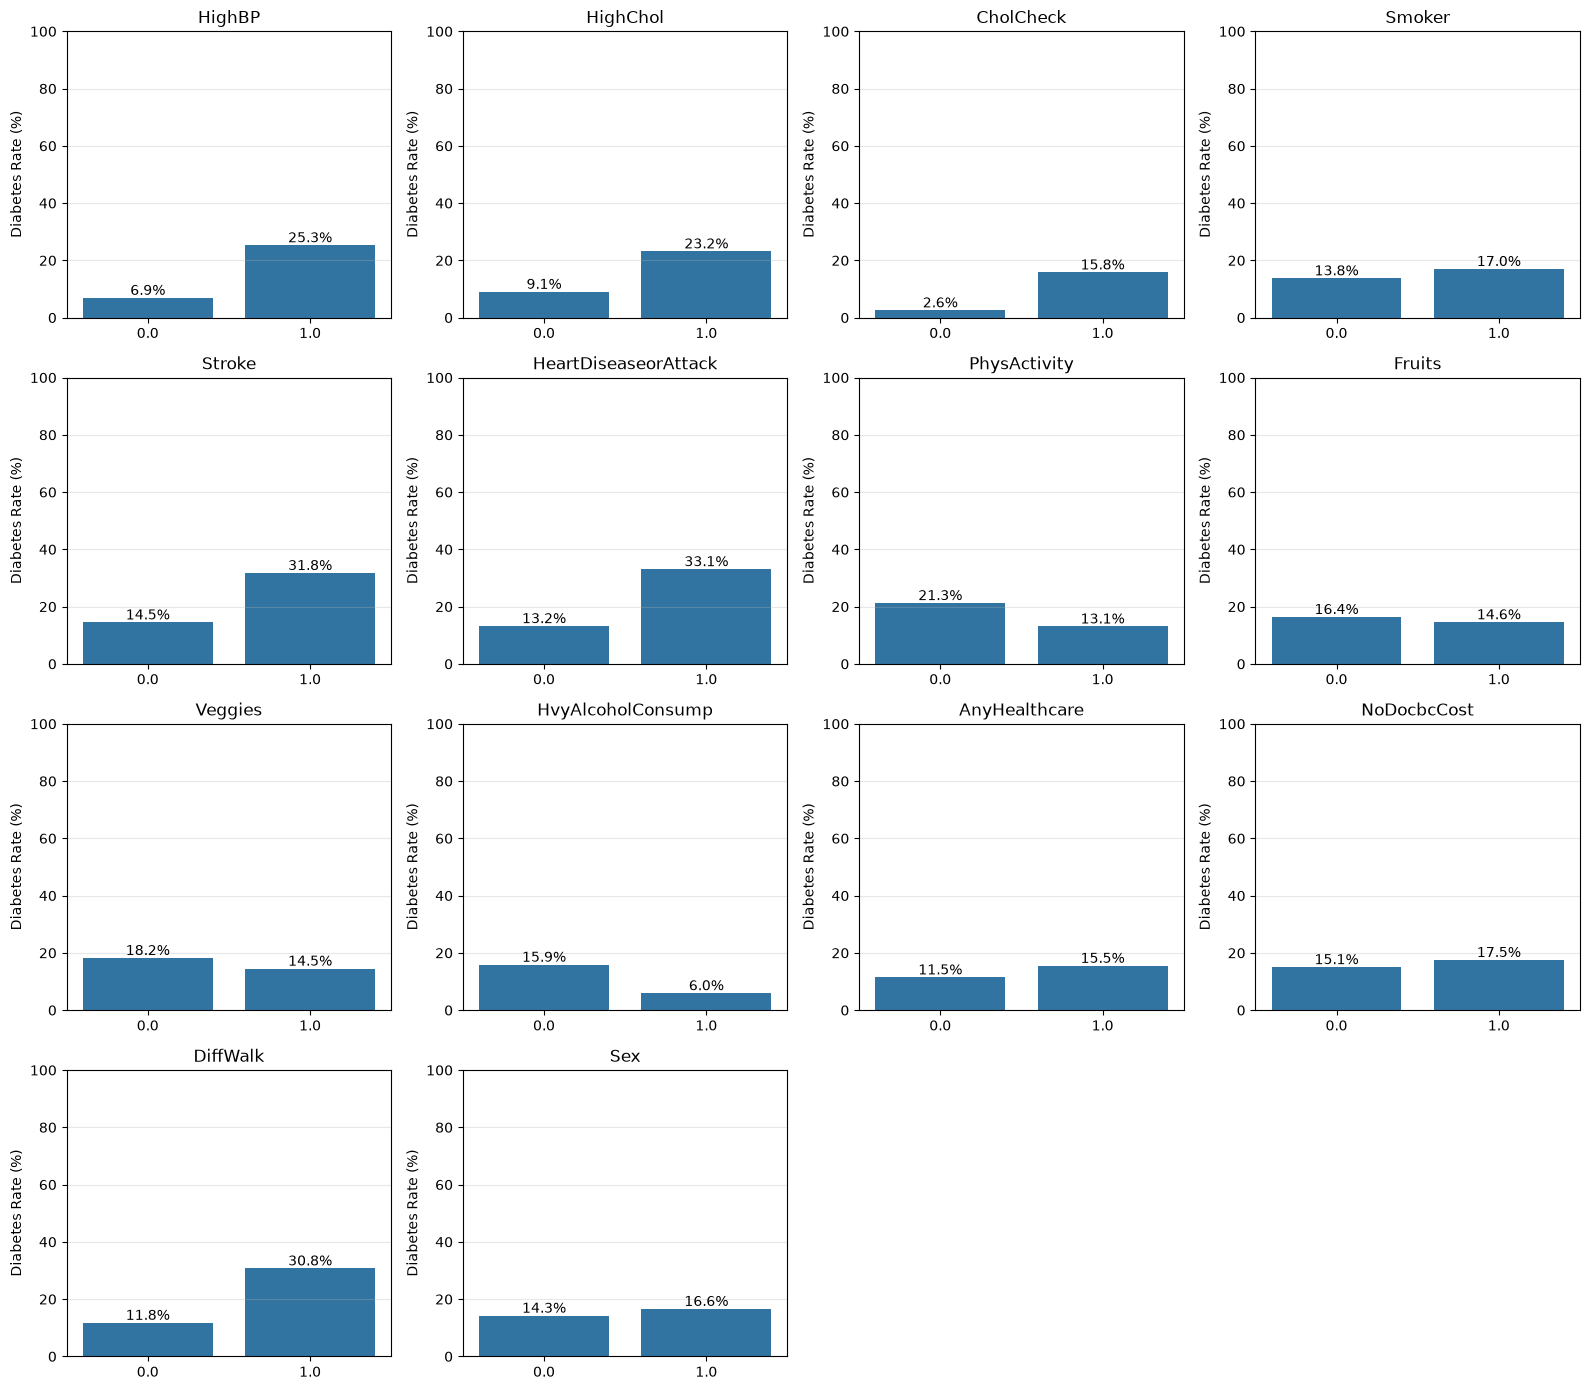

In [3]:
binary_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]
target_col = "Diabetes_binary"

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    rates = df.groupby(col)[target_col].mean() * 100

    sns.barplot(
        x=rates.index,
        y=rates.values,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Diabetes Rate (%)")
    axes[i].set_ylim(0, 100)
    axes[i].grid(axis="y", alpha=0.3)

    for j, value in enumerate(rates.values):
        axes[i].text(
            j,
            value + 1,
            f"{value:.1f}%",
            ha="center"
        )

for i in range(len(binary_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### 2. Chi-Square Test
- Test the statistical association between each binary feature and the target.
- Record the Chi-square statistic and p-value.

In [4]:
chi_results = []

for col in binary_cols:
    table = pd.crosstab(df[col], df[target_col])
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value
    })

chi_results_df = pd.DataFrame(chi_results)

chi_results_df.sort_values("p_value")

,Feature,Chi2,p_value
0,HighBP,14840.421805,0.000000e+00
1,HighChol,8719.656978,0.000000e+00
5,HeartDiseaseorAttack,6491.585745,0.000000e+00
4,Stroke,2256.534055,0.000000e+00
6,PhysActivity,2312.703694,0.000000e+00
12,DiffWalk,9670.630180,0.000000e+00
2,CholCheck,1205.929127,3.138608e-264
9,HvyAlcoholConsump,997.308681,6.906569e-219
3,Smoker,474.898448,2.753229e-105
8,Veggies,399.389542,7.478662e-89


### 3. Phi Coefficient
- Measure the strength of association between each binary feature and the target.
- Compare the Phi values across features.

In [5]:
phi_results = []

for col in binary_cols:
    table = pd.crosstab(df[col], df[target_col])

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.values.sum()
    phi = np.sqrt(chi2 / n)

    phi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value,
        "Phi": phi
    })

phi_results_df = pd.DataFrame(phi_results)

phi_results_df.sort_values("Phi", ascending=False)

,Feature,Chi2,p_value,Phi
0,HighBP,14840.421805,0.000000e+00,0.254306
12,DiffWalk,9670.630180,0.000000e+00,0.205287
1,HighChol,8719.656978,0.000000e+00,0.194932
5,HeartDiseaseorAttack,6491.585745,0.000000e+00,0.168193
6,PhysActivity,2312.703694,0.000000e+00,0.100391
4,Stroke,2256.534055,0.000000e+00,0.099164
2,CholCheck,1205.929127,3.138608e-264,0.072493
9,HvyAlcoholConsump,997.308681,6.906569e-219,0.065925
3,Smoker,474.898448,2.753229e-105,0.045492
8,Veggies,399.389542,7.478662e-89,0.041719


## Categorical Features Analysis

### 1. Categorical Features vs Target
- Visualize the relationship between each categorical feature and the target.
- Compare the target rate across categories.

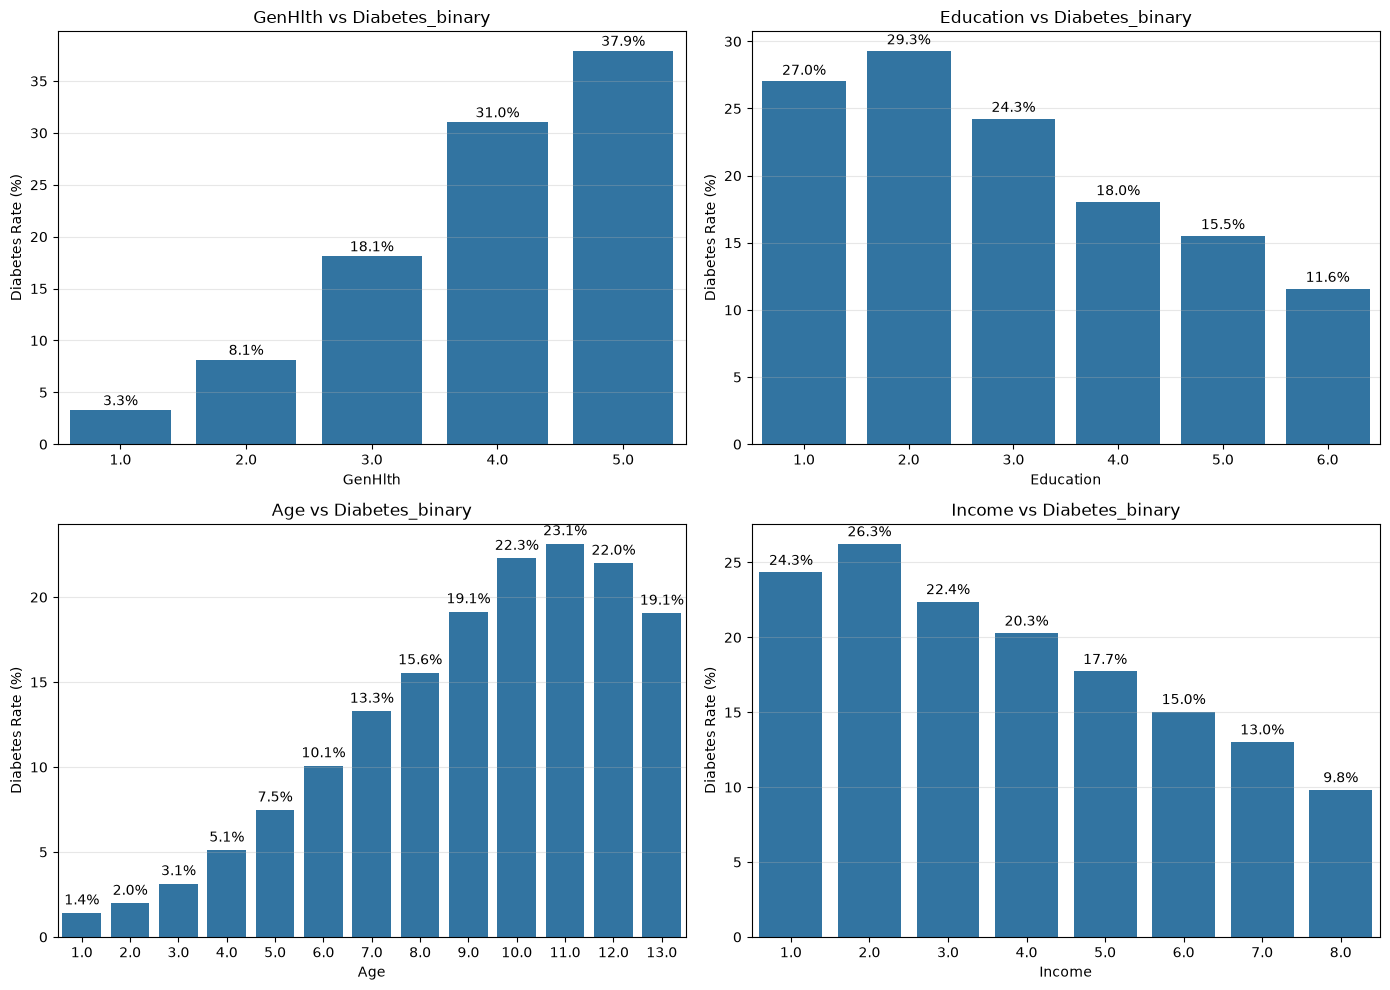

In [6]:
categorical_cols = [
    "GenHlth",
    "Education",
    "Age",
    "Income"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    rates = df.groupby(col)[target_col].mean() * 100

    sns.barplot(
        x=rates.index,
        y=rates.values,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs {target_col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Diabetes Rate (%)")
    axes[i].grid(axis="y", alpha=0.3)

    for j, value in enumerate(rates.values):
        axes[i].text(
            j,
            value + 0.5,
            f"{value:.1f}%",
            ha="center"
        )

plt.tight_layout()
plt.show()

### 2. Chi-Square Test
- Test the statistical association between each categorical feature and the target.
- Record the Chi-square statistic and p-value.

In [7]:
chi_results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df[target_col])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value
    })

categorical_chi_df = pd.DataFrame(chi_results)

categorical_chi_df.sort_values("p_value")

,Feature,Chi2,p_value
0,GenHlth,18193.703885,0.0
1,Education,2508.405362,0.0
2,Age,8207.831590,0.0
3,Income,4637.195742,0.0


### 3. Cramér's V
- Measure the strength of association between each categorical feature and the target.
- Compare the Cramér's V values across features.

In [8]:
cramer_results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df[target_col])

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.values.sum()
    r, k = table.shape

    cramer_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))

    cramer_results.append({
        "Feature": col,
        "Chi2": chi2,
        "p_value": p_value,
        "Cramer's V": cramer_v
    })

categorical_results_df = pd.DataFrame(cramer_results)

categorical_results_df.sort_values("Cramer's V", ascending=False)

,Feature,Chi2,p_value,Cramer's V
0,GenHlth,18193.703885,0.0,0.281575
2,Age,8207.831590,0.0,0.189124
3,Income,4637.195742,0.0,0.142155
1,Education,2508.405362,0.0,0.104552


## Continuous Features Analysis

### 1. Continuous Feature vs Target
- Visualize the distribution of the continuous feature across target classes.

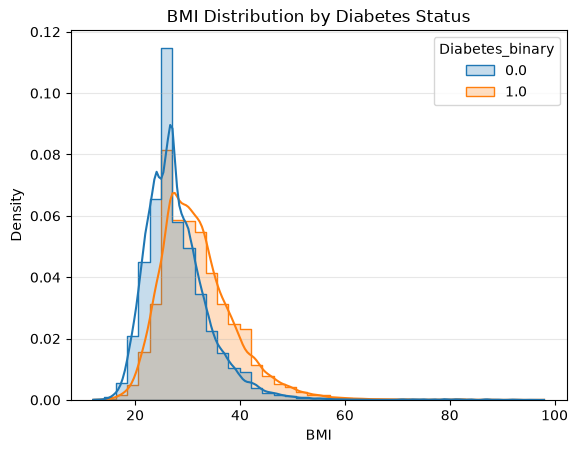

In [9]:
sns.histplot(
    data=df,
    x="BMI",
    hue=target_col,
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 2. Statistical Test
- Compare the distributions between target classes.
- Record the test statistic and p-value.

In [10]:
bmi_0 = df.loc[df[target_col] == 0, "BMI"]
bmi_1 = df.loc[df[target_col] == 1, "BMI"]

u_stat, p_value = mannwhitneyu(
    bmi_0,
    bmi_1,
    alternative="two-sided"
)

print("U statistic:", u_stat)
print("p-value:", p_value)

U statistic: 2220444097.0
p-value: 0.0


### 3. Effect Size
- Measure the strength of the difference between the distributions.

In [11]:
n1 = len(bmi_0)
n2 = len(bmi_1)

rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print("Rank-biserial correlation:", rank_biserial)

Rank-biserial correlation: 0.3490390022699643


## Bivariate Analysis — Summary

- The binary features showed different levels of association with the target. `HighBP`, `DiffWalk`, `HighChol`, and `HeartDiseaseorAttack` showed the strongest associations based on the Phi coefficient.

- All binary features showed statistically significant associations with the target based on the Chi-Square test. However, the strength of these associations varied considerably.

- The categorical and ordinal features also showed statistically significant associations with the target. `GenHlth` showed the strongest association based on Cramér's V, followed by `Age`, `Income`, and `Education`.

- The relationship between `BMI` and the target was statistically significant based on the Mann–Whitney U test (`p < 0.05`). The rank-biserial correlation was approximately `0.35`, indicating a noticeable difference between the BMI distributions across the two target classes.

- The analysis identified several features with noticeable associations with the target. These relationships will be considered during the next stages of analysis and modeling.

- Statistical significance was interpreted separately from association strength, especially given the large dataset size.